## Delievery Delay Analysis

#### P1 — Load, Clean & Merge

In [70]:
## Import required libraries

import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

In [71]:
## Load datasets

deliveries = pd.read_csv("../Datasets/Deliveries.csv")
routes = pd.read_csv("../Datasets/Routes.csv")

In [72]:
## Initial Data Check

print("Deliveries Data:")
deliveries

Deliveries Data:


,record_id,month,route_id,hub,promised_days,actual_days
0,1,Jan,R1,Mumbai,2,2
1,2,Jan,R2,Chennai,3,4
2,3,Jan,R3,Delhi,5,8
3,4,Jan,R4,Mumbai,6,10
4,5,Feb,R1,Chennai,2,5
5,6,Feb,R2,Delhi,3,3
6,7,Feb,R3,Delhi,5,10
7,8,Feb,R4,Chennai,6,7
8,9,Mar,R1,Delhi,2,8
9,10,Mar,R2,Mumbai,3,5


In [73]:
print("ROutes Data:")
routes

ROutes Data:


,route_id,route,service_type
0,R1,Metro Link,Express
1,R2,City Dash,Express
2,R3,Highway Freight,Standard
3,R4,Rural Feeder,Standard


In [74]:
print("\nDeliveries Shape:", deliveries.shape)
print("Routes Shape:", routes.shape)

print("\nDeliveries Information:")
print(deliveries.info())


Deliveries Shape: (13, 6)
Routes Shape: (4, 3)

Deliveries Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   record_id      13 non-null     int64 
 1   month          13 non-null     object
 2   route_id       13 non-null     object
 3   hub            13 non-null     object
 4   promised_days  13 non-null     int64 
 5   actual_days    13 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 756.0+ bytes
None


In [75]:
print("\nRoutes Information:")
print(routes.info())


Routes Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   route_id      4 non-null      object
 1   route         4 non-null      object
 2   service_type  4 non-null      object
dtypes: object(3)
memory usage: 228.0+ bytes
None


In [76]:
print("\nMissing Values in deliveries:")
print(deliveries.isnull().sum())

print("\nMissing Values in routes:")
print(routes.isnull().sum())

print("\nDuplicate Rows in deliveries:")
print(deliveries.duplicated().sum())

print("\nDuplicate Rows in routes:")
print(routes.duplicated().sum())


Missing Values in deliveries:
record_id        0
month            0
route_id         0
hub              0
promised_days    0
actual_days      0
dtype: int64

Missing Values in routes:
route_id        0
route           0
service_type    0
dtype: int64

Duplicate Rows in deliveries:
1

Duplicate Rows in routes:
0


In [77]:
deliveries[deliveries.duplicated()]

,record_id,month,route_id,hub,promised_days,actual_days
12,12,Mar,R4,Mumbai,6,15


In [78]:
deliveries_clean = deliveries.drop_duplicates().copy()

raw_count = len(deliveries)

clean_count = len(deliveries_clean)

duplicates_removed = raw_count - clean_count


print("Raw records:", raw_count)
print("Duplicates removed:", duplicates_removed)
print("Clean records:", clean_count)

Raw records: 13
Duplicates removed: 1
Clean records: 12


In [79]:
## Merge deliveries with routes

merged = deliveries_clean.merge(routes, on="route_id", how="left", validate="many_to_one")
merged

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express
1,2,Jan,R2,Chennai,3,4,City Dash,Express
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard
4,5,Feb,R1,Chennai,2,5,Metro Link,Express
5,6,Feb,R2,Delhi,3,3,City Dash,Express
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard
8,9,Mar,R1,Delhi,2,8,Metro Link,Express
9,10,Mar,R2,Mumbai,3,5,City Dash,Express


In [80]:
deliveries_clean.columns

Index(['record_id', 'month', 'route_id', 'hub', 'promised_days',
       'actual_days'],
      dtype='object')

In [81]:
## Merge validation

assert len(merged) == 12
assert merged["route"].notna().all()

#### P2 — Derived Field & Service-Type Analysis

In [82]:
## Create delay_days column

merged["delay_days"] = (deliveries["actual_days"] - deliveries["promised_days"]).clip(lower=0)
merged

,record_id,month,route_id,hub,promised_days,actual_days,route,service_type,delay_days
0,1,Jan,R1,Mumbai,2,2,Metro Link,Express,0
1,2,Jan,R2,Chennai,3,4,City Dash,Express,1
2,3,Jan,R3,Delhi,5,8,Highway Freight,Standard,3
3,4,Jan,R4,Mumbai,6,10,Rural Feeder,Standard,4
4,5,Feb,R1,Chennai,2,5,Metro Link,Express,3
5,6,Feb,R2,Delhi,3,3,City Dash,Express,0
6,7,Feb,R3,Delhi,5,10,Highway Freight,Standard,5
7,8,Feb,R4,Chennai,6,7,Rural Feeder,Standard,1
8,9,Mar,R1,Delhi,2,8,Metro Link,Express,6
9,10,Mar,R2,Mumbai,3,5,City Dash,Express,2


In [83]:
## Overall Summary

total_delay_days = merged["delay_days"].sum()

delay_incident_rate = (merged["actual_days"] > merged["promised_days"])

highest_delay_days = merged["delay_days"].max()

lowest_delay_days = merged["delay_days"].min()


print("Overall Summary:")
print("\nTOtal Delay Days: ", total_delay_days)
print("Highest delay Days: ", highest_delay_days)
print("Lowest delay Days: ", lowest_delay_days)

Overall Summary:

TOtal Delay Days:  34
Highest delay Days:  9
Lowest delay Days:  0


In [87]:
merged["is_delayed"] = (merged["actual_days"] > merged["promised_days"])

In [89]:
service_summary = (merged.groupby("service_type").agg(
                total_delay_days=("delay_days", "sum"),
                delay_incidence_rate=("is_delayed", "mean")
        ).reset_index()
)

# Convert incidence rate from decimal to percentage
service_summary["delay_incidence_rate"] = (service_summary["delay_incidence_rate"] * 100).round(2)


In [90]:
route_delay = (merged.groupby("route_id")["delay_days"].sum())


greatest_route = route_delay.idxmax()
greatest_route_delay = route_delay.max()

In [91]:
## Calculate route's share of overall delay

overall_delay = merged["delay_days"].sum()

greatest_route_share = (greatest_route_delay / overall_delay * 100)

In [95]:
print("Service Type Summary:")
service_summary

print("\nRoute with Greatest:")
print("Route:", greatest_route)
print("Total delay days:", greatest_route_delay)

print("Share of overall delay:",round(greatest_route_share, 2),"%")

Service Type Summary:

Route with Greatest:
Route: R4
Total delay days: 14
Share of overall delay: 41.18 %


## P3 — Chart & Exports

In [96]:
## Monthly Calculation

month_order = ["Jan", "Feb", "Mar"]

monthly_delay = (merged.groupby("month")["delay_days"].sum().reindex(month_order))

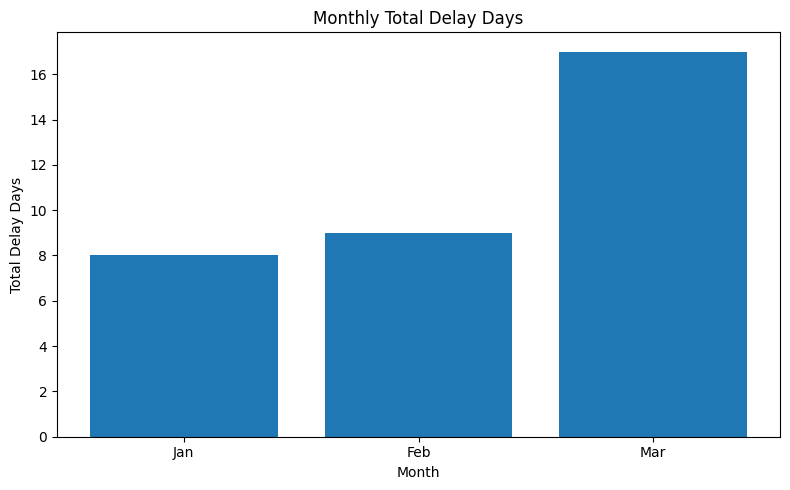

In [97]:
## Plot Bar Chart

plt.figure(figsize=(8, 5))

plt.bar(monthly_delay.index, monthly_delay.values)
plt.title("Monthly Total Delay Days")
plt.xlabel("Month")
plt.ylabel("Total Delay Days")
plt.tight_layout()

In [100]:
## Save chart as png

plt.savefig("../Outputs/python_chart.png", dpi=300, bbox_inches="tight")
plt.close()

print("\nChart saved successfully.")


Chart saved successfully.


In [102]:
## Export Clean Data

merged.to_csv("../Outputs/clean_data.csv", index=False)

print("Clean merged data exported.")

Clean merged data exported.


In [103]:
## Export Python Summary

## Export Clean Data

service_summary.to_csv("../Outputs/python_summary.csv", index=False)

print("Python Summary exported.")

Python Summary exported.
